In [1]:
import sys
import os

import matplotlib.pyplot as plt
import numpy as np

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from my_nn import (
    MLP,
    accuracy,
    load_mnist,
    train_epoch_sgd,
    build_optimizer_state,
)

In [2]:
x_train, y_train, x_test, y_test = load_mnist()

In [3]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 784), (60000,), (10000, 784), (10000,))

In [4]:
model = MLP(
    input_dim=784,
    hidden_dims=[96, 64],
    num_classes=10,
    init_method="normal_small",
    dropout_p=0.0,
    seed=42,
)
model

In [5]:
train_losses = []
train_accs = []
test_accs = []
opt_state = build_optimizer_state(model, "sgd")

In [6]:
epochs = 40

for epoch in range(1, epochs + 1):
    tl, ta = train_epoch_sgd(
        model,
        x_train,
        y_train,
        batch_size=32,
        lr=0.3,
        l2_lambda=0.0,
        optimizer="sgd",
        opt_state=opt_state,
    )
    logits_te = model.forward(x_test, train=False)
    te_acc = accuracy(logits_te, y_test)
    train_losses.append(tl)
    train_accs.append(ta)
    test_accs.append(te_acc)
    if epoch % 5 == 0 or epoch == 1:
        print(
            f"epoch {epoch:3d}  train_loss={tl:.4f}  train_acc={ta:.4f}  test_acc={te_acc:.4f}"
        )

epoch   1  train_loss=0.4512  train_acc=0.9520  test_acc=0.9494
epoch   5  train_loss=0.0555  train_acc=0.9837  test_acc=0.9710
epoch  10  train_loss=0.0307  train_acc=0.9832  test_acc=0.9689
epoch  15  train_loss=0.0243  train_acc=0.9921  test_acc=0.9758
epoch  20  train_loss=0.0189  train_acc=0.9921  test_acc=0.9742
epoch  25  train_loss=0.0227  train_acc=0.9927  test_acc=0.9749
epoch  30  train_loss=0.0155  train_acc=0.9964  test_acc=0.9789
epoch  35  train_loss=0.0182  train_acc=0.9945  test_acc=0.9769
epoch  40  train_loss=0.0151  train_acc=0.9947  test_acc=0.9772


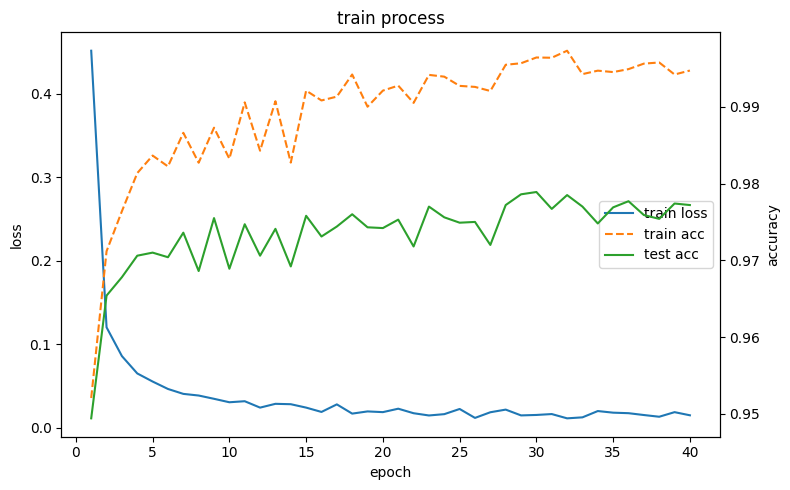

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, epochs + 1), train_losses, label="train loss", color="C0")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax2 = ax.twinx()
ax2.plot(
    range(1, epochs + 1), train_accs, label="train acc", color="C1", linestyle="--"
)
ax2.plot(range(1, epochs + 1), test_accs, label="test acc", color="C2")
ax2.set_ylabel("accuracy")
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [ln.get_label() for ln in lines], loc="center right")
ax.set_title("train process")
fig.tight_layout()
fig.savefig("./curve.png", dpi=150)